# Embeddings by ESM2

In [1]:
import torch
import esm
import numpy as np
import csv
from tqdm import tqdm
import os

In [2]:
print(torch.__version__)        # Check PyTorch version
print(torch.cuda.is_available())  # Check if CUDA is available
print(torch.version.cuda)        # Check CUDA version

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
print("CUDA Version:", torch.version.cuda)
print("cuDNN Version:", torch.backends.cudnn.version())

2.10.0+cu130
True
13.0
PyTorch Version: 2.10.0+cu130
CUDA Available: True
CUDA Version: 13.0
cuDNN Version: 91501


In [3]:
# Load the ESM2 model
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
#model, alphabet = esm.pretrained.esm2_t36_3B_UR50D()
#model, alphabet = esm.pretrained.esm2_t48_15B_UR50D()
batch_converter = alphabet.get_batch_converter()
model = model.eval().to("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
# Prepare your protein sequences (list of tuples with identifier and sequence)
data = [
    ("protein1", "MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHGKKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFKLLSHCLLVTLAAHLPAEFTPAVHASLDKFLASVSTVLTSKYR")]

# Convert sequences to tokens
batch_labels, batch_strs, batch_tokens = batch_converter(data)
batch_lens = (batch_tokens != alphabet.padding_idx).sum(1)

# Move tokens to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
batch_tokens = batch_tokens.to(device)

# Extract per-residue representations
with torch.no_grad():
    results = model(batch_tokens, repr_layers=[33], return_contacts=True)

# Get the embeddings per-residue from the desired layer. 
# NOTE: per-residue embeddings have the same shape for all sequences because it adds padding to max length sequence in data
# NOTE: per-residue embeddings includes start and end tokens (max length in data + 2)

token_embeddings = results["representations"][33]  

# For each sequence, compute per-sequence embeddings by averaging the token embeddings
residue_embeddings = []
sequence_embeddings = []
for i, tokens_len in enumerate(batch_lens):
    # Exclude special tokens (start and end)
    resemb = token_embeddings[i, 1 : tokens_len - 1]
    seqemb = resemb.mean(0)
    residue_embeddings.append((batch_labels[i], resemb.cpu()))
    sequence_embeddings.append((batch_labels[i], seqemb.cpu()))

print('per-residue Embeddings:')
for label, embedding in residue_embeddings:
    print(f"Sequence: {label}")
    print(f'per-residue Embedding shape: {embedding.shape}')
    print(embedding)

print('#'*100)

print('per-sequence Embeddings:')
for label, embedding in sequence_embeddings:
    print(f"Sequence: {label}")
    print(f"per-sequence Embedding shape: {embedding.shape}")
    print(embedding)

per-residue Embeddings:
Sequence: protein1
per-residue Embedding shape: torch.Size([142, 1280])
tensor([[ 0.0885, -0.0480, -0.1979,  ...,  0.1160, -0.1668,  0.0896],
        [-0.0312, -0.1130, -0.1069,  ..., -0.0397,  0.1307, -0.0028],
        [ 0.1404, -0.0454,  0.2095,  ..., -0.3218,  0.1281, -0.1644],
        ...,
        [-0.0327,  0.0859, -0.0794,  ..., -0.1715, -0.0158,  0.1223],
        [-0.0630, -0.2817, -0.4596,  ..., -0.1983, -0.2152,  0.0537],
        [ 0.1858,  0.1359, -0.2181,  ..., -0.6579,  0.1424,  0.1862]])
####################################################################################################
per-sequence Embeddings:
Sequence: protein1
per-sequence Embedding shape: torch.Size([1280])
tensor([-0.0089, -0.1366, -0.1565,  ..., -0.1954,  0.0617,  0.0617])


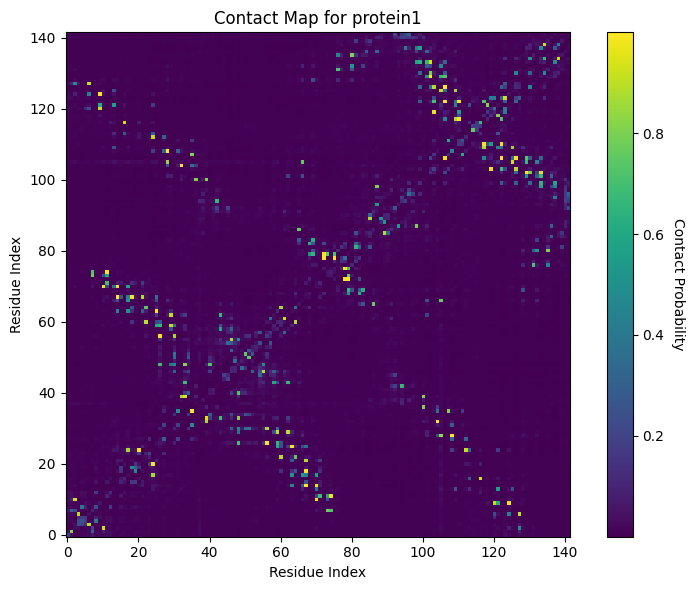

In [5]:
try:
    import matplotlib.pyplot as plt
    import numpy as np

    # Iterate over your data, sequence lengths, and contact maps
    for (label, seq), tokens_len, attention_contacts in zip(data, batch_lens, results["contacts"]):
        # Extract the relevant portion of the contact map
        contact_map = attention_contacts.cpu().numpy()[:tokens_len, :tokens_len]

        # Create a new figure with a defined size
        plt.figure(figsize=(8, 6))

        # Display the contact map with an appropriate colormap
        plt.imshow(contact_map, cmap='viridis', origin='lower', interpolation='nearest')

        # Add a colorbar to indicate the scale
        cbar = plt.colorbar()
        cbar.set_label('Contact Probability', rotation=270, labelpad=15)

        # Set axis labels and title
        plt.xlabel('Residue Index')
        plt.ylabel('Residue Index')
        plt.title(f'Contact Map for {label}')

        # Enhance layout
        plt.tight_layout()

        # Display the plot
        plt.show()

except ImportError:
    pass  # Matplotlib is not available
